# CDC over MCP — tools, schemas and example calls

Every CDC series reaches consumers through meida's MCP server, but by two
different routes:

- **Socrata** (`data.cdc.gov`) has a live API, so its ~2,500 series are
  fetched on demand with `cdc_series_data`.
- **WONDER** and **NVSR** cannot be fetched per request — WONDER is throttled
  to ~1 query per 2 minutes behind a bot filter, and NVSR is annual Excel
  downloads with no programmatic URL discovery. meida pulls them once into a
  Postgres table and serves them with `timeseries_source_data`.

This notebook walks the server: what tools exist, what arguments they take,
and one worked call against each of the three sources.

**Requires the MCP server to be running** — `python -m mcp_server.server`.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
from collections import Counter
from matplotlib import pyplot
from lib import config

sys.path.append('../')

from utils import (
    list_mcp_tools,
    show_tool_schema,
    show_columns,
    get_dataset_facets,
    get_rows,
    cdc_rows_to_arrays,
    plot_cdc_series,
    plot_stored_series,
    plot_stored_series_group,
    catalog_concepts,
    search_catalog,
    list_stored_series,
    get_stored_series,
    list_stale_series,
    stored_series_to_arrays,
)

pyplot.style.use(config.glyfish_style)

## 1. Discovery — every tool on the server

The server exposes one tool family per data source. Names are prefixed by
source (`fred_`, `bls_`, `bis_`, `cdc_`, `tiingo_`), except the stored-series
tools, which are deliberately generic: `timeseries_source_*` takes the source
as an argument, so a new file-delivered source needs no new tool.

In [2]:
await list_mcp_tools()

fred_category_children: List the child categories for a FRED category.
fred_category_series: List the series contained within a FRED category.
fred_series_info: Fetch metadata for a single FRED series.
fred_series_observations: Return observations for a series (limit defaults to 100).
fred_series_updates: Return recently updated FRED series.
list_releases: List FRED releases — the publications data arrives in, such as the Employment Situation or the H.15 selected interest rates. Returns the release ids that fred_release_series takes.
fred_release_series: List the series that belong to a FRED release.
tiingo_series_info: Fetch metadata for a Tiingo ticker (ETF, mutual fund, or stock), including its available date range.
tiingo_price_series: Return the end-of-day price series (OHLCV plus split/dividend-adjusted prices) for a Tiingo ticker. Provide start_date/end_date as YYYY-MM-DD for a range; omit for the latest day.
bls_series_data: Fetch observations for one or more BLS series IDs (up

## 2. Tool schemas

### Socrata — `cdc_series_data`

One series per call, selected by **naming its facets**. No SoQL crosses the
wire: the parameter names are the catalog's `facets` metadata keys, so a value
read off a discovered series passes straight back in under the same name, and
the server owns every column name and literal.

That indirection is not ceremony — the same facet is a different column in
every dataset. `race` is the column `race` on `w9j2-ggv5`, the pair
`group`/`subgroup` on `w26f-tf3h`, `stratificationcategory1`/`stratification1`
on `hksd-2xuw`, and a composed `stub_label` on `9j2v-jamp`.

The facet enums below are the **union across datasets**; no dataset defines
all of them. `cdc_dataset_facets` reports the per-dataset subset.

In [3]:
_ = await show_tool_schema('cdc_series_data')

cdc_series_data
  Return one CDC time series, selected by naming its facets. Facet names and tokens are the catalog's metadata keys, so a value read off a discovered series passes straight back in. Enums are the union across datasets — see cdc_dataset_facets for what one dataset actually defines. Several datasets stratify one demographic at a time, so age and race together is usually a series that was never published.

  dataset_id   string   required
                        one of: 489q-934x, 9j2v-jamp, hksd-2xuw, w26f-tf3h, w9j2-ggv5, xkb8-kh2a
  concept      string   optional
                        one of: alcohol_binge, alcohol_consumption, chronic_liver_mortality, drug_overdose, life_expectancy, mortality, suicide
  state        string   optional
                        one of: AK, AL, AR, AZ, CA, CO, CT, DC, DE, FL, GA, GU, ... (56 total)
  race         string   optional
                        one of: aian, all, asian, asian_pi, black, hispanic, multiracial, nhpi, white
  sex  

### Socrata — `cdc_dataset_facets`

The per-dataset subset of those union enums. Several of these datasets
stratify **one dimension at a time**, so `age` and `race` together usually
describes a series that was never published — this is how to check before
asking, and an unsupported token also comes back naming what is valid.

`concept` is optional here, unlike on `cdc_series_data`. The registry is keyed
by `(dataset_id, concept)` because neither is unique alone — `w9j2-ggv5` serves
two concepts, `suicide` spans four datasets — but the facet vocabulary is
usually shared, so a concept is asked for only when it actually changes the
answer. The two cells below are the contrast.

In [4]:
_ = await show_tool_schema('cdc_dataset_facets')

cdc_dataset_facets
  The facet tokens one CDC dataset actually defines — the per-dataset subset of cdc_series_data's union enums. Use it to check what is available before querying, or after an unsupported-token error.

  dataset_id   string   required
                        one of: 489q-934x, 9j2v-jamp, hksd-2xuw, w26f-tf3h, w9j2-ggv5, xkb8-kh2a
  concept      string   optional
                        one of: alcohol_binge, alcohol_consumption, chronic_liver_mortality, drug_overdose, life_expectancy, mortality, suicide


In [5]:
# w9j2-ggv5 serves life_expectancy and mortality with identical facets,
# so no concept is needed
print('w9j2-ggv5')
await get_dataset_facets('w9j2-ggv5')

w9j2-ggv5
  race       ['all', 'black', 'white']
  sex        ['both', 'female', 'male']


{'race': ['all', 'black', 'white'], 'sex': ['both', 'female', 'male']}

In [6]:
# hksd-2xuw genuinely differs — alcohol_consumption publishes no
# demographic breakdowns at all — so omitting the concept is an error here
try:
    await get_dataset_facets('hksd-2xuw')
except Exception as e:
    print(f'{type(e).__name__}: {e}\n')

print('hksd-2xuw / alcohol_consumption')
await get_dataset_facets('hksd-2xuw', 'alcohol_consumption')

print('\nhksd-2xuw / alcohol_binge')
await get_dataset_facets('hksd-2xuw', 'alcohol_binge')

RuntimeError: MCP tool error: 'Error executing tool cdc_dataset_facets: dataset hksd-2xuw publishes different facets per concept -- pass concept: alcohol_binge, alcohol_consumption, chronic_liver_mortality'

hksd-2xuw / alcohol_consumption
  state      ['<any postal code>']

hksd-2xuw / alcohol_binge
  age        ['18-44', '45-64', '65+']
  race       ['aian', 'asian', 'black', 'hispanic', 'multiracial', 'nhpi', 'white']
  rate_type  ['age_adjusted', 'crude']
  sex        ['female', 'male']
  state      ['<any postal code>']


{'sex': ['female', 'male'],
 'race': ['aian',
  'asian',
  'black',
  'hispanic',
  'multiracial',
  'nhpi',
  'white'],
 'age': ['18-44', '45-64', '65+'],
 'state': ['<any postal code>'],
 'rate_type': ['age_adjusted', 'crude']}

### Socrata — `cdc_dataset_columns`

In [7]:
_ = await show_tool_schema('cdc_dataset_columns')

cdc_dataset_columns
  Describe a CDC dataset's columns (field name, type, label) from its id — use it to see which fields to filter/select in cdc_series_data. CDC datasets have inconsistent schemas, so check columns before querying.

  dataset_id   string   required


### Stored series — `timeseries_source_list` and `timeseries_source_data`

`source` is `cdc_wonder` or `cdc_nvsr`; `native_id` comes from the listing.
`frequency` is only needed if an id is ambiguous, which none currently are.

In [8]:
_ = await show_tool_schema('timeseries_source_list')

timeseries_source_list
  List stored time series held in meida's database — sources that cannot be fetched per request, currently CDC WONDER (cause-of-death rates: alcohol, drug, suicide, homicide, firearm, chronic liver, deaths of despair) and CDC NVSR (life expectancy / life tables). Returns identity and coverage without observations, as {'series': [...]}. Optional 'source' filters to cdc_wonder or cdc_nvsr.

  source       string   optional


In [9]:
_ = await show_tool_schema('timeseries_source_data')

timeseries_source_data
  Return one stored time series in full, with its observations, from meida's database (CDC WONDER cause-of-death rates, CDC NVSR life expectancy). 'source' is cdc_wonder or cdc_nvsr and 'native_id' is the series identifier from timeseries_source_list. Pass 'frequency' only if an id is ambiguous. Observation values are strings — cast as needed.

  source       string   required
  native_id    string   required
  frequency    string   optional


### Discovering the stored inventory

180 series: 9 cause-of-death rates from WONDER, 171 life-expectancy series
from NVSR (18 national by race × sex, 153 state by sex).

Note what is **not** here — Socrata. `timeseries_source_list` enumerates only
what is stored in Postgres, and Socrata has a live API so its observations are
never stored. The catalog in §2.5 below is what covers both.

In [10]:
stored = await list_stored_series()
print(f'{len(stored)} stored series')

180 stored series


In [11]:
from collections import Counter
for source, count in Counter(s['source'] for s in stored).items():
    print(f'  {source:12} {count:4}')


  cdc_nvsr      171
  cdc_wonder      9


### Wonder Series Info

In [12]:
for s in await list_stored_series('cdc_wonder'):
    print(f"  {s['native_id']:56} {s['observation_start']}..{s['observation_end']}")


  cdc/alcohol_induced/wonder/national/age_adjusted         1999-01-01..2024-01-01
  cdc/cardiometabolic/wonder/national/age_adjusted         1999-01-01..2024-01-01
  cdc/chronic_liver_mortality/wonder/national/age_adjusted 1999-01-01..2024-01-01
  cdc/despair_composite/wonder/national/age_adjusted       1999-01-01..2024-01-01
  cdc/drug_induced/wonder/national/age_adjusted            1999-01-01..2024-01-01
  cdc/drug_overdose/wonder/national/age_adjusted           1999-01-01..2024-01-01
  cdc/firearm/wonder/national/age_adjusted                 1999-01-01..2024-01-01
  cdc/homicide/wonder/national/age_adjusted                1999-01-01..2024-01-01
  cdc/suicide/wonder/national/age_adjusted                 1999-01-01..2024-01-01


## 2.5 The catalog — which series exist

`timeseries_source_list` answers "what is stored"; `series_catalog_search`
answers "what exists", across **both** routes. Every Socrata series was
previously reachable only if you already knew its facets — the catalog YAML
that knew they existed was gitignored build output no runtime code read.

Each entry carries a `retrieval` block naming the tool that fetches it, and a
`facets` block whose keys are exactly the arguments that tool takes — so a row
read here passes straight back into `cdc_series_data`.

Filters are exact, not fuzzy. Descriptions are generated per *bucket* of
series that differ only by facet value, so 1,014 `alcohol_binge` series share
four description strings: prose cannot separate them, facets can.

In [13]:
# the coarse map: what is measured, and by which dataset
_ = await catalog_concepts()

   1014  alcohol_binge              hksd-2xuw
    750  chronic_liver_mortality    hksd-2xuw
    424  drug_overdose              xkb8-kh2a
    327  life_expectancy            -
     52  alcohol_consumption        hksd-2xuw
     42  suicide                    9j2v-jamp
     28  suicide                    w26f-tf3h
      9  mortality                  w9j2-ggv5
      9  life_expectancy            w9j2-ggv5
      6  chronic_liver_mortality    489q-934x
      6  suicide                    489q-934x
      6  drug_overdose              489q-934x
      1  alcohol_induced            -
      1  suicide                    -
      1  despair_composite          -
      1  drug_induced               -
      1  homicide                   -
      1  firearm                    -
      1  chronic_liver_mortality    -
      1  drug_overdose              -
      1  cardiometabolic            -


In [14]:
# narrow by facet — 'total' is counted before the limit, so a truncated
# result is distinguishable from a complete one
_ = await search_catalog(concept='alcohol_binge', state='TX')

  21 matching series (20 returned, limit=20)
    cdc/alcohol_binge/hksd-2xuw/state=tx/age_adjusted
      {'state': 'TX', 'rate_type': 'age_adjusted'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw/state=tx/age=18-44/crude
      {'age': '18-44', 'state': 'TX', 'rate_type': 'crude'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw/state=tx/age=45-64/crude
      {'age': '45-64', 'state': 'TX', 'rate_type': 'crude'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw/state=tx/age=65+/crude
      {'age': '65+', 'state': 'TX', 'rate_type': 'crude'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw/state=tx/crude
      {'state': 'TX', 'rate_type': 'crude'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw/state=tx/race=aian/age_adjusted
      {'race': 'aian', 'state': 'TX', 'rate_type': 'age_adjusted'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw/state=tx/race=aian/crude
      {'race': 'aian', 'state': 'TX', 'rate_type': 'crude'} -> cdc_series_data
    cdc/alcohol_binge/hksd-2xuw

In [15]:
# one concept, both routes: suicide is published live by three Socrata
# datasets and stored once from WONDER. verbose=False keeps all 77 but
# prints only the summary line instead of listing them.
entries = await search_catalog(concept='suicide', limit=200, verbose=False)

for tool, n in Counter((e.get('retrieval') or {}).get('tool') for e in entries).items():
    print(f'  {n:4}  {tool}')
for dataset, n in sorted(Counter(e['dataset_id'] for e in entries).items(),
                         key=lambda kv: -kv[1]):
    print(f'  {n:4}  {dataset or "(stored)"}')

# and a catalog row feeds straight back into the fetch tool
hit = next(e for e in entries if e['retrieval']['tool'] == 'cdc_series_data')
rows = await get_rows(hit['dataset_id'], concept=hit['concept'], **hit['facets'])
print(f"\n  {hit['series_id']}\n  -> {len(rows)} rows, {rows[0]['year']}..{rows[-1]['year']}")

  77 matching series (77 returned)
    76  cdc_series_data
     1  timeseries_source_data
    42  9j2v-jamp
    28  w26f-tf3h
     6  489q-934x
     1  (stored)

  cdc/suicide/489q-934x/quarterly/age_adjusted
  -> 11 rows, 2023 Q1..2025 Q3


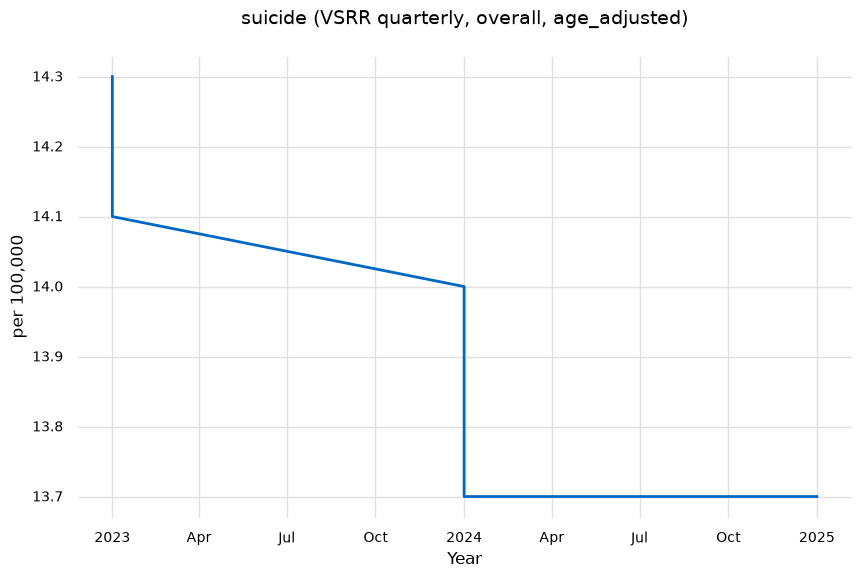

In [16]:
# the series discovered above, plotted straight from the catalog's facets
plot_cdc_series(rows, 'year', 'value',
                title=hit['title'], ylabel=hit['units'] or 'value')


## 3. Example call — Socrata

Life expectancy at birth, 1900–2018, from `w9j2-ggv5`. Socrata returns every
value as a string, so casting is the caller's job — `cdc_rows_to_arrays`
handles it.

In [17]:
_ = await show_columns('w9j2-ggv5')

w9j2-ggv5: NCHS - Death rates and life expectancy at birth
  year                             number   Year
  race                             text     Race
  sex                              text     Sex
  average_life_expectancy          number   Average Life Expectancy (Years)
  mortality                        number   Age-adjusted Death Rate


In [18]:
await get_dataset_facets('w9j2-ggv5')

  race       ['all', 'black', 'white']
  sex        ['both', 'female', 'male']


{'race': ['all', 'black', 'white'], 'sex': ['both', 'female', 'male']}

In [19]:
socrata_rows = await get_rows(
    'w9j2-ggv5',
    concept='life_expectancy',
    race='all',
    sex='both',
)
print(f'{len(socrata_rows)} rows; first and last:')
print(' ', socrata_rows[0])
print(' ', socrata_rows[-1])

119 rows; first and last:
  {'year': '1900', 'value': '47.3'}
  {'year': '2018', 'value': '78.7'}


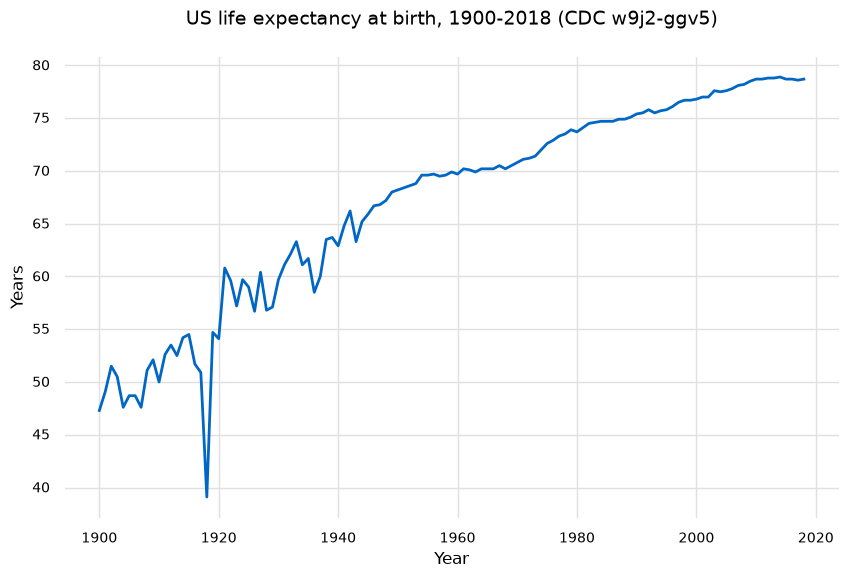

In [20]:
# Socrata rows come back as {'year', 'value'} — the same pair for every
# dataset, which is what makes one plot helper enough
plot_cdc_series(socrata_rows, 'year', 'value',
                title='US life expectancy at birth, 1900-2018 (CDC w9j2-ggv5)',
                ylabel='Years')


### A monthly series — and the period Socrata cannot build

`w9j2-ggv5` above is the easy shape: one column identifies an observation, so
`year` is the label. `xkb8-kh2a` is not. It publishes monthly but keys each row
by `year` **and** `month`, so selecting the time column alone returns twelve
rows per year all carrying the same label — twelve points claiming one period,
in whatever order the API sent them.

Socrata cannot fold them: there is no `concat()`, and `||` returns an empty
result rather than an error. So the server selects both columns and composes
`2020-01` itself, then sorts — `$order=year` would leave the months arbitrary,
and adding `month` sorts them alphabetically, April first.

In [21]:
overdose = await get_rows(
    'xkb8-kh2a',
    concept='drug_overdose',
    state='OH',
    drug='heroin',
    year_start=2019,
    year_end=2021,
)
print(f'{len(overdose)} monthly points, {overdose[0]["year"]} .. {overdose[-1]["year"]}')
for row in overdose:
    print(' ', row)


36 monthly points, 2019-01 .. 2021-12
  {'year': '2019-01', 'value': '718'}
  {'year': '2019-02', 'value': '712'}
  {'year': '2019-03', 'value': '701'}
  {'year': '2019-04', 'value': '696'}
  {'year': '2019-05', 'value': '673'}
  {'year': '2019-06', 'value': '665'}
  {'year': '2019-07', 'value': '656'}
  {'year': '2019-08', 'value': '622'}
  {'year': '2019-09', 'value': '599'}
  {'year': '2019-10', 'value': '574'}
  {'year': '2019-11', 'value': '565'}
  {'year': '2019-12', 'value': '536'}
  {'year': '2020-01', 'value': '492'}
  {'year': '2020-02', 'value': '465'}
  {'year': '2020-03', 'value': '439'}
  {'year': '2020-04', 'value': '431'}
  {'year': '2020-05', 'value': '431'}
  {'year': '2020-06', 'value': '409'}
  {'year': '2020-07', 'value': '377'}
  {'year': '2020-08', 'value': '355'}
  {'year': '2020-09', 'value': '333'}
  {'year': '2020-10', 'value': '315'}
  {'year': '2020-11', 'value': '290'}
  {'year': '2020-12', 'value': '293'}
  {'year': '2021-01', 'value': '286'}
  {'year': '

Worth reading the number before plotting it. Every value is a **12-month-ending
count**, not that month's deaths: December 2020 is the twelve months *ending* in
December. Consecutive points therefore overlap by eleven months, which is why
the line is so smooth — it is a trailing annual total, not a monthly one.

Two consequences: differencing neighbours gives `deaths(m) − deaths(m−12)`
rather than a monthly figure, and the December point alone is the calendar-year
total. `frequency: monthly` describes when it is published, not what it
measures.

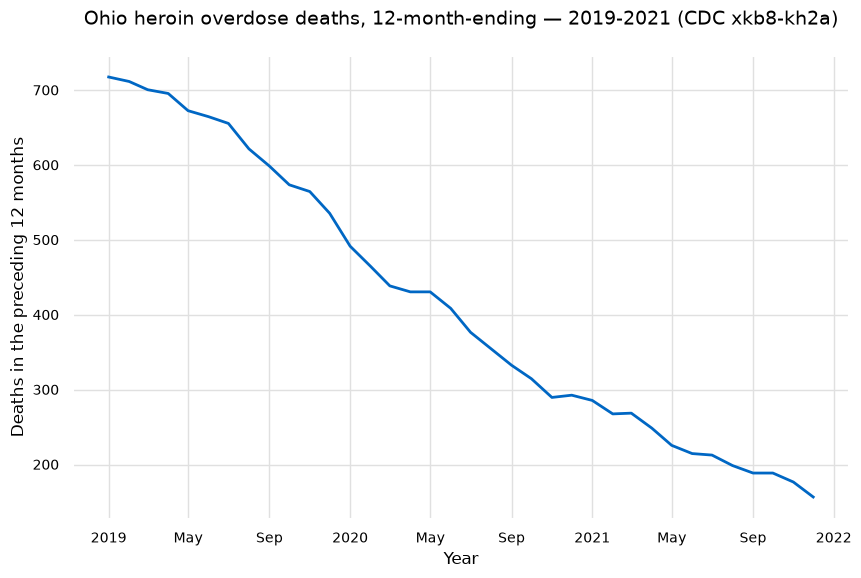

In [22]:
plot_cdc_series(
    overdose, 'year', 'value',
    title='Ohio heroin overdose deaths, 12-month-ending — 2019-2021 (CDC xkb8-kh2a)',
    ylabel='Deaths in the preceding 12 months',
)

## 4. Example call — NVSR

Life expectancy from the NCHS life tables. This is the **only** channel
publishing US life expectancy by race after 2020 — no public API carries it,
and WONDER has none at all. Note the full precision: `78.971`, not the
published `79.0`.

In [23]:
nvsr = await get_stored_series('cdc_nvsr', 'cdc/life_expectancy/nvsr/race=all/sex=both')
print(nvsr['title'])
print(f"  {nvsr['units']} | {nvsr['observation_count']} obs | stale={nvsr['stale']}")
print(f"  {nvsr['metadata']['cdc_nvsr']['definition'][0]}\n")
for obs in nvsr['observations']:
    print(f"  {obs['date'][:4]}  {obs['value']}")


Life expectancy at birth, United States (all races, both sexes)
  years | 4 obs | stale=False
  NCHS decennial-method period life table (NVSR United States Life Tables)

  2021  76.3702
  2022  77.4569
  2023  78.4214
  2024  78.971


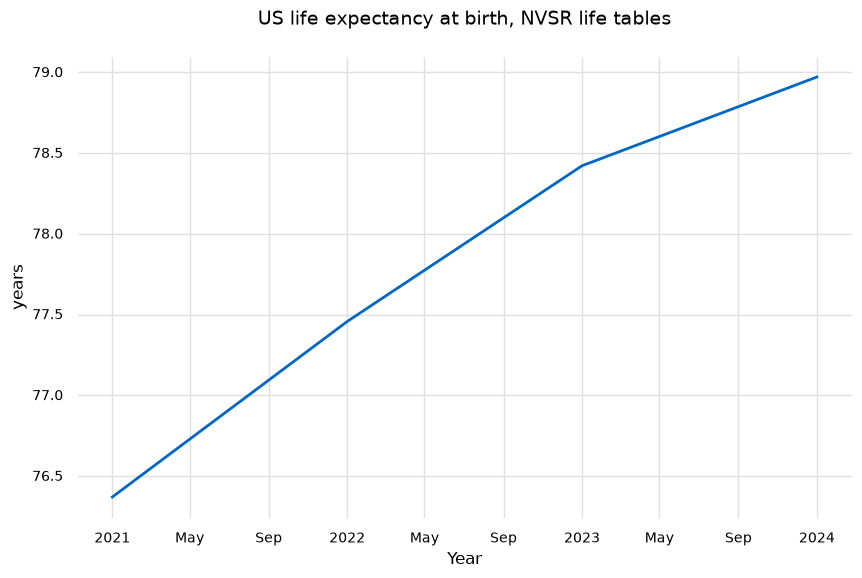

In [24]:
plot_stored_series(nvsr, title='US life expectancy at birth, NVSR life tables')

### The race gap, 2024

Six origin/race groups, from the 18 national series.

In [25]:
for s in sorted(await list_stored_series('cdc_nvsr'), key=lambda x: x['native_id']):
    if s['native_id'].endswith('sex=both') and 'state=' not in s['native_id']:
        full = await get_stored_series('cdc_nvsr', s['native_id'])
        latest = full['observations'][-1]
        race = full['metadata']['cdc_nvsr']['race'][0]
        print(f"  {race:10} {latest['date'][:4]}  {latest['value']:>8}")


  aian_nh    2024   71.1493
  all        2024    78.971
  asian_nh   2024   85.7916
  black_nh   2024   74.7693
  hispanic   2024   81.8139
  white_nh   2024   78.9304


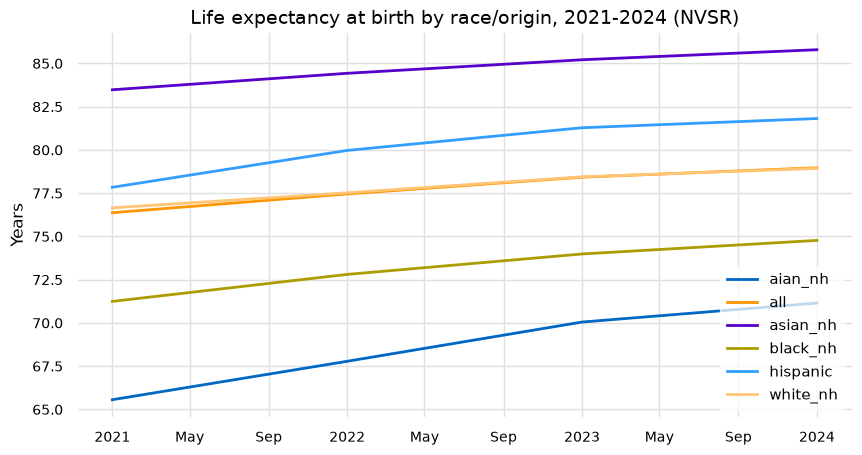

In [26]:
# the gap as series rather than a single year: six groups, 2021-2024
national = [s for s in sorted(await list_stored_series('cdc_nvsr'),
                              key=lambda x: x['native_id'])
            if s['native_id'].endswith('sex=both') and 'state=' not in s['native_id']]
full = [await get_stored_series('cdc_nvsr', s['native_id']) for s in national]
labels = [s['metadata']['cdc_nvsr']['race'][0] for s in full]

plot_stored_series_group(full, labels,
                         title='Life expectancy at birth by race/origin, 2021-2024 (NVSR)',
                         ylabel='Years')


### The state tables — 51 jurisdictions, 2018–2022

A different cut of the same life tables: no race dimension, but every state
and DC, each split total/male/female. 153 series, and until the 2018–2021
volumes were downloaded they carried a single 2022 point each — enough to
rank states, not enough to say anything about time.

NVSR names the files `{ST}1/2/3` with no label inside, and ships a fourth,
`{ST}4`, that holds **standard errors** rather than a life table. The builder
skips it, which is why 204 workbooks a year become 153 series.

In [27]:
states = sorted(s['native_id'] for s in await list_stored_series('cdc_nvsr')
                if 'state=' in s['native_id'] and s['native_id'].endswith('sex=both'))
by_state = {n.split('state=')[1].split('/')[0]: await get_stored_series('cdc_nvsr', n)
            for n in states}
print(f"{len(by_state)} jurisdictions, "
      f"{by_state['NY']['observation_start'][:4]}-{by_state['NY']['observation_end'][:4]}")

def year(state, y):
    obs = by_state[state]['observations']
    return next(float(o['value']) for o in obs if o['date'][:4] == str(y))


51 jurisdictions, 2018-2022


#### The 2020 shock was not evenly shared — and 2020 was not the worst year

The 2019→2020 fall runs from **−0.25** years in Hawaii to **−2.92** in New
York, a factor of twelve across jurisdictions living through the same pandemic
year. But that ranking maps where the *first wave* landed, not the damage:
only **12 of 51** jurisdictions bottomed out in 2020. **37 bottomed out in
2021**, and 39 were still falling that year — West Virginia lost more in 2021
(−1.85) than it had in 2020, and Alaska lost 2.10.


In [28]:
drops = sorted((year(st, 2020) - year(st, 2019), st) for st in by_state)
print('steepest 2019->2020 fall        shallowest')
for (d_lo, st_lo), (d_hi, st_hi) in zip(drops[:5], reversed(drops[-5:])):
    print(f'  {st_lo}  {d_lo:+.2f}                      {st_hi}  {d_hi:+.2f}')

# but 2020 is not where most states bottomed out
troughs = Counter(min(range(2018, 2023), key=lambda y: year(st, y)) for st in by_state)
print('\nworst year:', ', '.join(f'{y} {n}' for y, n in sorted(troughs.items())))
print('still falling in 2021:',
      sum(1 for st in by_state if year(st, 2021) < year(st, 2020)), 'of', len(by_state))

back = [st for st in by_state if year(st, 2022) >= year(st, 2019)]
print(f'back to their 2019 level by 2022: {len(back)} of {len(by_state)}')


steepest 2019->2020 fall        shallowest
  NY  -2.92                      HI  -0.25
  DC  -2.76                      NH  -0.41
  LA  -2.66                      ME  -0.55
  NJ  -2.61                      WA  -0.78
  MS  -2.55                      OR  -0.78

worst year: 2020 12, 2021 37, 2022 2
still falling in 2021: 39 of 51
back to their 2019 level by 2022: 0 of 51


The plot shows both patterns at once. New York is the 2020 story: a sharp fall
and the strongest rebound, 1.78 years regained by 2022. West Virginia is the
2021 story — lowest in the country throughout, and its trough a year later
than New York's. Hawaii barely registered 2020 at all and then slid anyway.

Read the shapes rather than a single year's ranking, and **no state has
recovered its 2019 figure.**


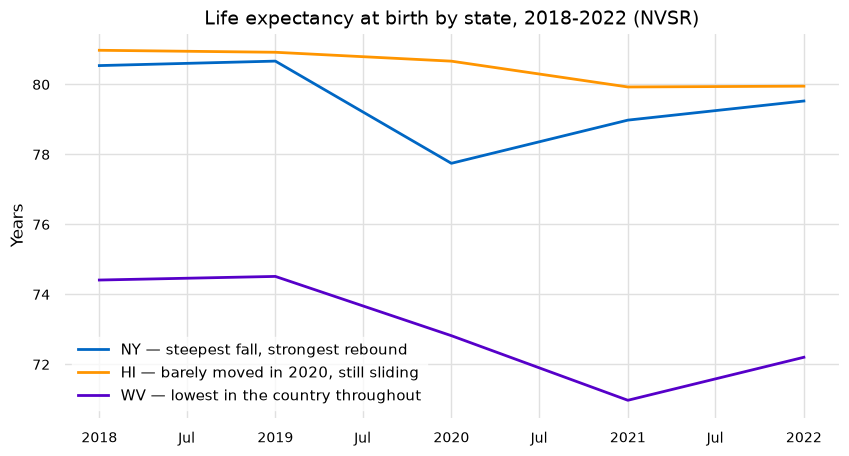

In [29]:
plot_stored_series_group(
    [by_state[st] for st in ('NY', 'HI', 'WV')],
    ['NY — steepest fall, strongest rebound',
     'HI — barely moved in 2020, still sliding',
     'WV — lowest in the country throughout'],
    title='Life expectancy at birth by state, 2018-2022 (NVSR)',
    ylabel='Years')


#### Where you live outweighs which sex you are

The state tables carry male and female separately, so both gaps are
measurable against each other. The female–male gap averages 5.29 years and
ranges from 3.58 (Utah) to 6.88 (New Mexico) — but the geographic spread is
wider still: **men in Massachusetts outlive women in West Virginia.**

In [30]:
gaps = []
for st in by_state:
    pair = {sex: await get_stored_series(
                'cdc_nvsr', f'cdc/life_expectancy/nvsr/state={st}/sex={sex}')
            for sex in ('female', 'male')}
    f, m = (float(pair[s]['observations'][-1]['value']) for s in ('female', 'male'))
    gaps.append((f - m, st, f, m))
gaps.sort()

print('2022 female-male gap')
print('  narrowest ', '  '.join(f'{st} {g:.2f}' for g, st, _, _ in gaps[:4]))
print('  widest    ', '  '.join(f'{st} {g:.2f}' for g, st, _, _ in gaps[-4:]))
print(f'  mean       {sum(g for g, _, _, _ in gaps) / len(gaps):.2f}')

worst_f = min((f, st) for _, st, f, _ in gaps)
best_m = max((m, st) for _, st, _, m in gaps)
print(f'\nlowest female: {worst_f[1]} {worst_f[0]:.2f}'
      f'   highest male: {best_m[1]} {best_m[0]:.2f}')


2022 female-male gap
  narrowest  UT 3.58  ID 4.19  SD 4.31  MN 4.54
  widest     MS 6.24  DC 6.30  LA 6.59  NM 6.88
  mean       5.29

lowest female: WV 75.14   highest male: MA 77.41


## 5. Example call — WONDER

Cause-of-death rates, age-adjusted to the 2000 US standard population. Each
series is stitched from two databases: D76 (1999–2020) and D158 (2018–2024),
which agree exactly on their overlap.

The `excluded_codes` field is worth reading — WONDER rejects the NCHS
pseudo-codes `*U01`/`*U02`/`*U03`, so the suicide, homicide, firearm and
composite series omit terrorism-reclassified deaths.

In [31]:
wonder = await get_stored_series(
    'cdc_wonder', 'cdc/despair_composite/wonder/national/age_adjusted'
)
meta = wonder['metadata']['cdc_wonder']
print(wonder['title'])
print(f"  {wonder['units']} | {wonder['observation_count']} obs")
print(f"  {meta['definition'][0]}")
print(f"  excluded: {meta.get('excluded_codes')}\n")

dates, values = stored_series_to_arrays(wonder)
for year in (1999, 2019, 2021, 2024):
    v = next(v for d, v in zip(dates, values) if d.year == year)
    print(f'  {year}  {v}')


Deaths of despair (alcohol, drug-induced and suicide), age-adjusted rate, United States
  deaths per 100,000 | 26 obs
  Set union of the alcohol-induced, drug-induced and suicide code sets, queried as one request -- summing the separate series would double-count the codes they share
  excluded: ['*U03']

  1999  23.2
  2019  45.7
  2021  60.8
  2024  48.6


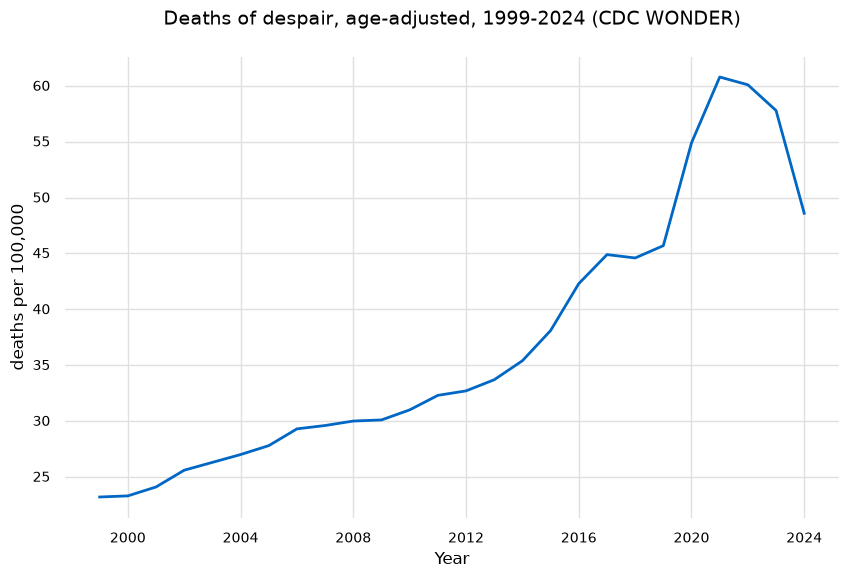

In [32]:
plot_stored_series(wonder,
                   title='Deaths of despair, age-adjusted, 1999-2024 (CDC WONDER)')


### The despair components together

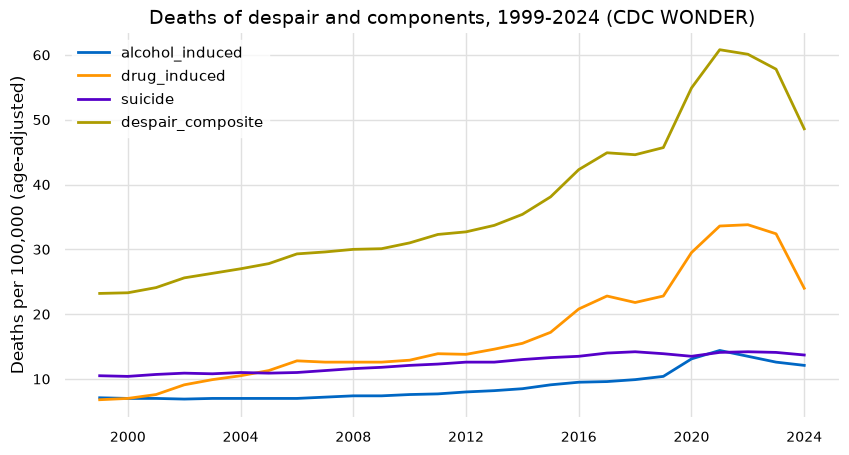

In [33]:
concepts = ['alcohol_induced', 'drug_induced', 'suicide', 'despair_composite']
components = [await get_stored_series('cdc_wonder',
                                      f'cdc/{c}/wonder/national/age_adjusted')
              for c in concepts]

plot_stored_series_group(components, concepts,
                         title='Deaths of despair and components, 1999-2024 (CDC WONDER)',
                         ylabel='Deaths per 100,000 (age-adjusted)')


## 6. What needs refreshing

Neither source can re-fetch itself, so `timeseries_source_stale` replaces a
polling process: ask what is past its horizon when you want to know. Series
are still served while stale — for annual data, weeks late beats missing.

In [34]:
stale = await list_stale_series()
print(f'{len(stale)} series due for a refresh')
for s in stale[:10]:
    print(f"  {s['source']:12} {s['native_id']}")


0 series due for a refresh
